<a href="https://colab.research.google.com/github/hoangthythytran-arch/data-analytics-project/blob/main/Game_behavior_vs_purchase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Clean, visualize, and analyze the given dataset, and then summarize the findings.

## Clean Data
This task aims to get to know the data better, develop hypotheses, identify patterns or anomalies, and pinpoint any potential problems with the dataset. We'll also consider how to improve this dataset in the future.

In [ ]:
import pandas as pd
import kagglehub
import os # Import the os module to handle paths

path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'online_gaming_behavior_dataset.csv')

# Load the dataset into a pandas DataFrame named df
df = pd.read_csv(csv_file_path)

# Inspect the first few rows of the DataFrame
df.head()

100%|██████████| 904k/904k [00:00<00:00, 977kB/s]

Extracting files...


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


**Reasoning**:
After loading the dataset, the next step in data cleaning is to inspect its structure, data types, and check for missing values. This will help us understand the dataset better before performing any cleaning operations.



In [ ]:
# Display summary statistics for numerical columns
display(df.describe())

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    display(df[col].value_counts())


--- Column: Gender ---
Unique values: 2


,count
Gender,
Male,23959
Female,16075



--- Column: Location ---
Unique values: 4


,count
Location,
USA,16000
Europe,12004
Asia,8095
Other,3935



--- Column: GameGenre ---
Unique values: 5


,count
GameGenre,
Sports,8048
Action,8039
Strategy,8012
Simulation,7983
RPG,7952



--- Column: GameDifficulty ---
Unique values: 3


,count
GameDifficulty,
Easy,20015
Medium,12011
Hard,8008



--- Column: EngagementLevel ---
Unique values: 3


,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


**Reasoning**:
The dataset has been inspected for missing values, and it was found that there are none. The next step is to check for and remove duplicate rows to ensure data uniqueness, as per the subtask instructions.



In [ ]:
print('Checking for missing values and duplicates...')

# Handle missing values (although df.isnull().sum() showed none)
# For robustness, we still include this step as per instructions
df.dropna(inplace=True)
print(f'Number of rows after dropping missing values: {len(df)}')

# Fill missing value
# Select only numeric columns for mean calculation and filling
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
print(f'Number of rows after filling missing values: {len(df)}')

# Check for duplicate rows
duplicates_before = df.duplicated().sum()
print(f'Number of duplicate rows before removal: {duplicates_before}')

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify duplicates have been removed
duplicates_after = df.duplicated().sum()
print(f'Number of duplicate rows after removal: {duplicates_after}')

# Review data types again after cleaning (as per instructions, although no changes are expected if no conversions were made)
df.info()

Checking for missing values and duplicates...
Number of rows after dropping missing values: 40034
Number of rows after filling missing values: 40034
Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non

-**Hypotheses:** We could hypothesize that higher play times correlate with more in-game purchases or higher engagement levels. We might also expect regional differences in game genre preferences or spending habits.

-**Patterns:** Look for patterns in age distribution across different game genres, the relationship between 'PlayTimeHours' and 'InGamePurchases' or 'EngagementLevel'. Are there specific 'GameGenre' or 'Location' types that show significantly higher 'SessionsPerWeek' or 'AvgSessionDurationMinutes'?->>NEED VISUALIZE.

-**Anomalies:** Outliers in 'PlayTimeHours', 'SessionsPerWeek', or 'AvgSessionDurationMinutes' could indicate highly dedicated players or data entry errors. Anomalies might also appear in 'InGamePurchases' if there are players with extremely high spending compared to the average. Unusual distributions in categorical features (e.g., a very low count for a specific 'GameGenre' that is generally popular) could also be anomalies. ->>NEED VISUALIZE.

-**Problems with the Data:**

+Potential Biases: Not clear on how the data was collected (e.g., only surveying players from certain platforms or demographics).

+Limited Features: We might lack important features like device used, social interaction in-game, motivation for playing, or specific game titles within a genre. This limits the depth of analysis.

+Temporal Aspect: Without a timestamp for purchases or play sessions, we cannot analyze trends over time, which is crucial for gaming behavior.

-**How to Improve this Dataset in the Future:**

+More Timestamps: Include exact timestamps for play sessions and purchases to enable time-series analysis and identify peak activity times.
Player Demographics: Collect more detailed demographic information (e.g., occupation, income range, education level, exact age rather than age groups if applicable) while ensuring privacy.

+Behavioral Metrics: Include more in-depth behavioral data like social interaction metrics (e.g., number of friends, chat frequency), types of in-game activities performed, or progression data.

+Feedback/Satisfaction Data: Incorporate player satisfaction scores or feedback to understand the correlation between engagement and enjoyment.

+Longitudinal Data: Collect data over a longer period to observe changes in player behavior, engagement, and purchasing patterns over time.

## Visualize Data

In [ ]:
# =========================
# VISUALIZATION SETUP
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

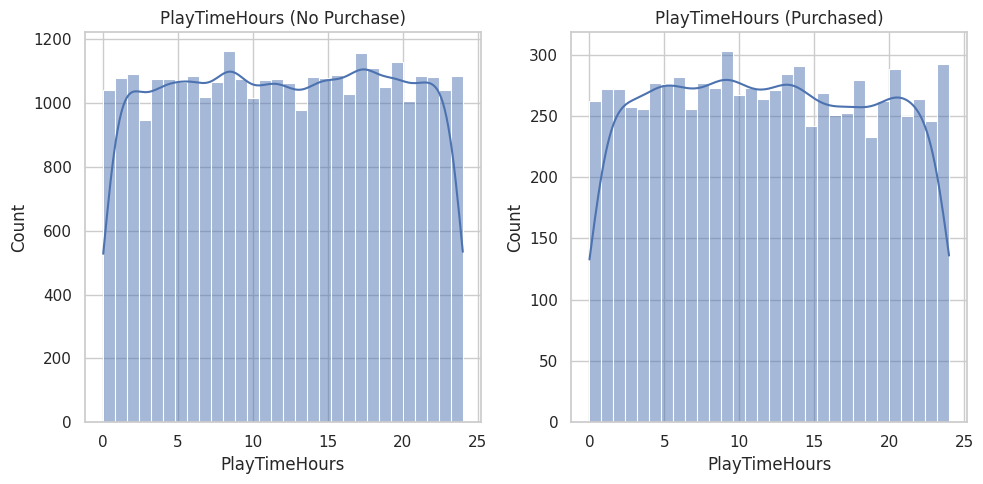

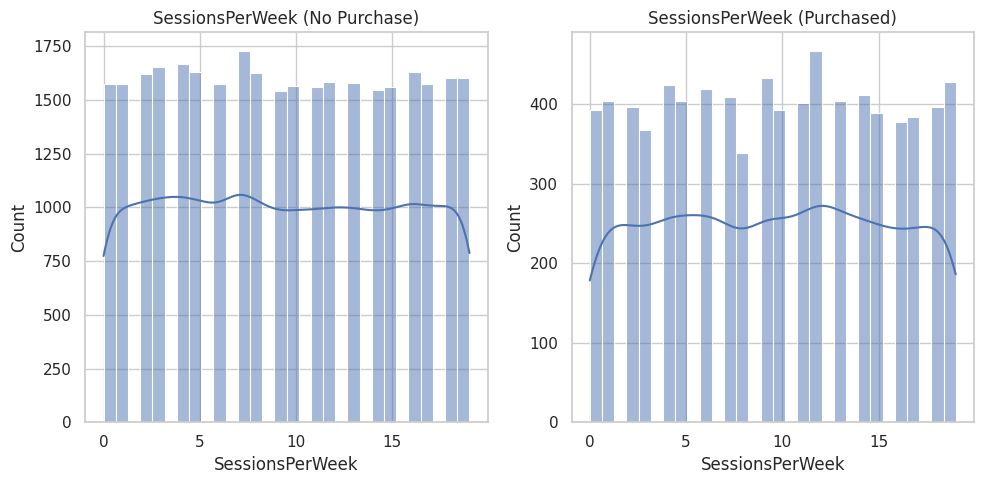

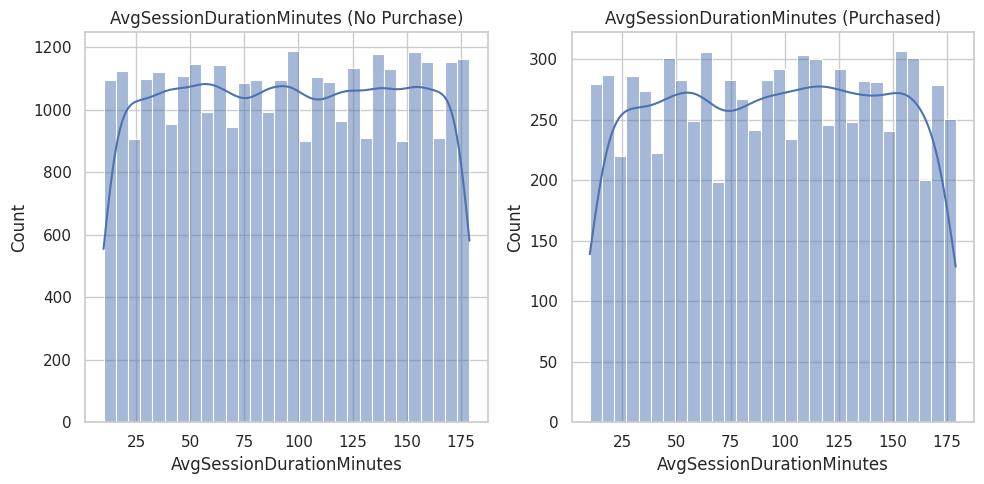

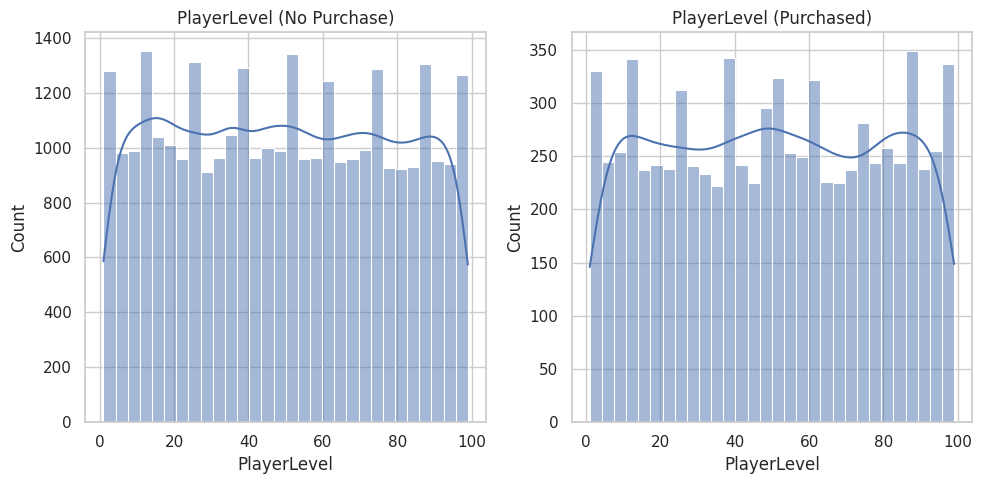

In [ ]:
behavior_cols = ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel']

for col in behavior_cols:
    plt.figure(figsize=(10,5))

    # No Purchase
    plt.subplot(1,2,1)
    sns.histplot(df[df['InGamePurchases']==0][col], bins=30, kde=True)
    plt.title(f'{col} (No Purchase)')

    # Purchase
    plt.subplot(1,2,2)
    sns.histplot(df[df['InGamePurchases']==1][col], bins=30, kde=True)
    plt.title(f'{col} (Purchased)')

    plt.tight_layout()
    plt.show()

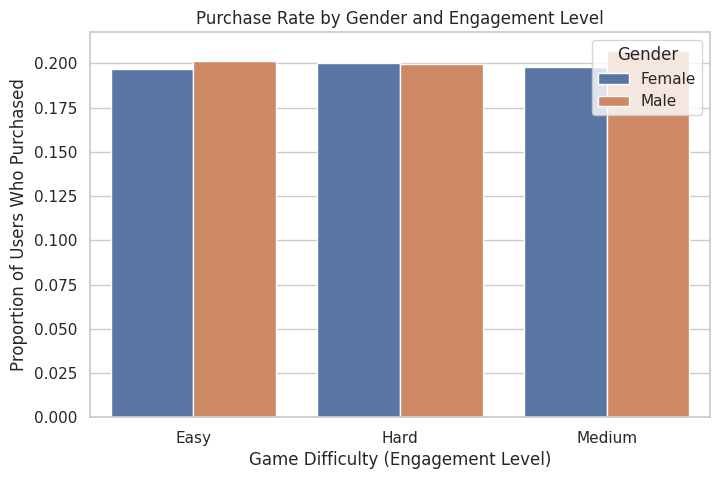

In [ ]:
# =========================
# PURCHASE RATE BY GENDER & DIFFICULTY
# =========================

purchase_rate = df.groupby(['Gender', 'GameDifficulty'])['InGamePurchases'].mean().reset_index()

plt.figure()
sns.barplot(data=purchase_rate, x='GameDifficulty', y='InGamePurchases', hue='Gender')
plt.title('Purchase Rate by Gender and Engagement Level')
plt.xlabel('Game Difficulty (Engagement Level)')
plt.ylabel('Proportion of Users Who Purchased')
plt.show()

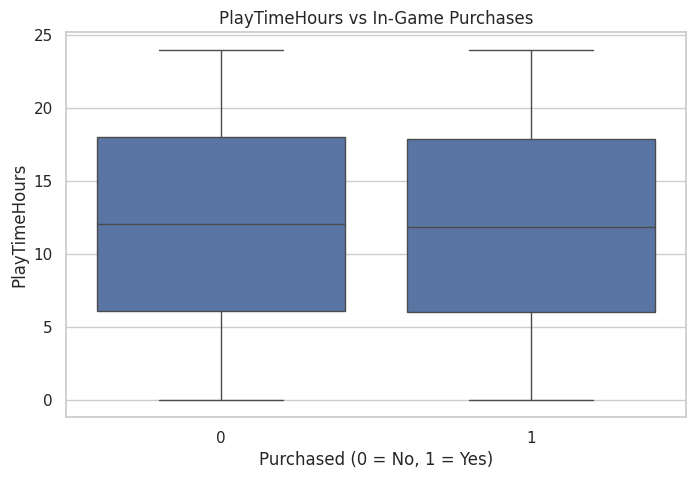

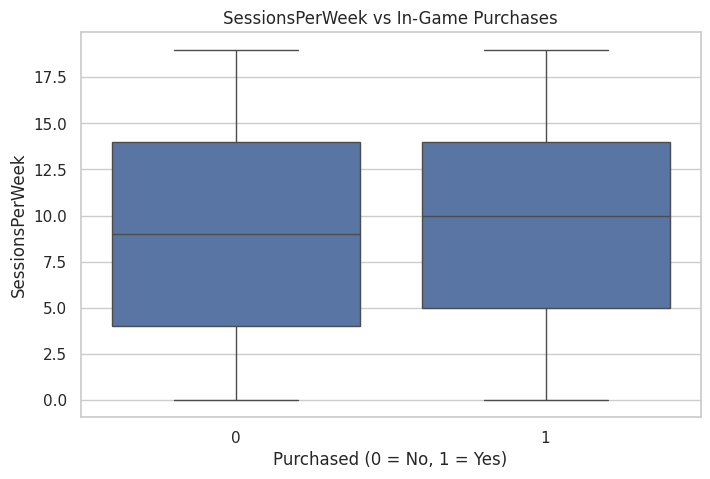

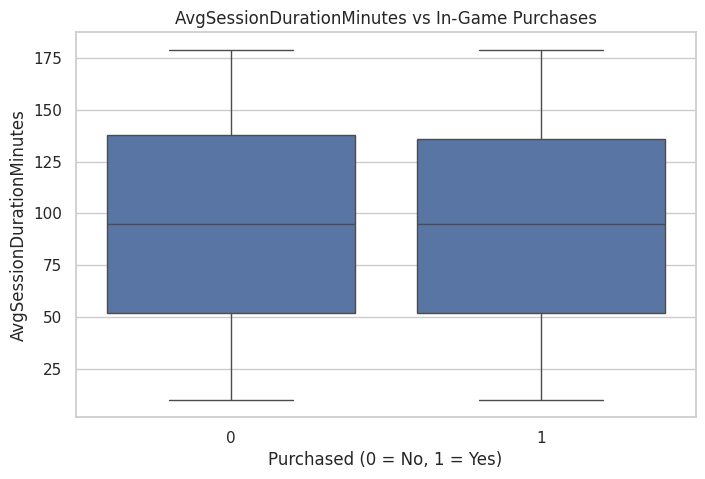

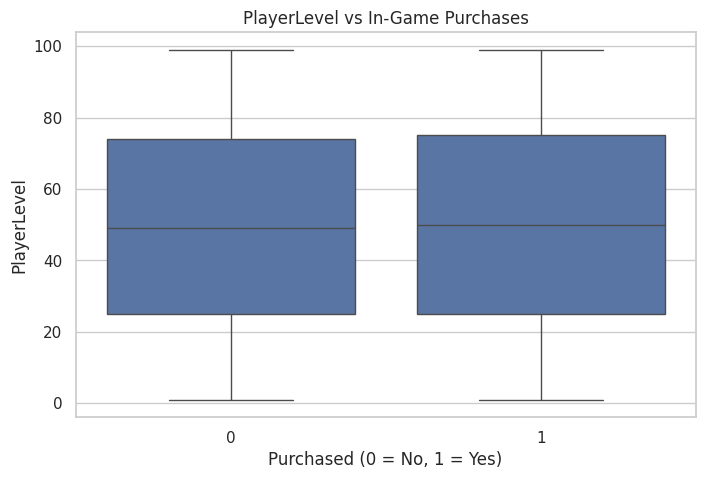

In [ ]:
# =========================
# BEHAVIOR vs PURCHASES (BOXPLOTS)
# =========================

behavior_cols = ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel']

for col in behavior_cols:
    plt.figure()
    sns.boxplot(data=df, x='InGamePurchases', y=col)
    plt.title(f'{col} vs In-Game Purchases')
    plt.xlabel('Purchased (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

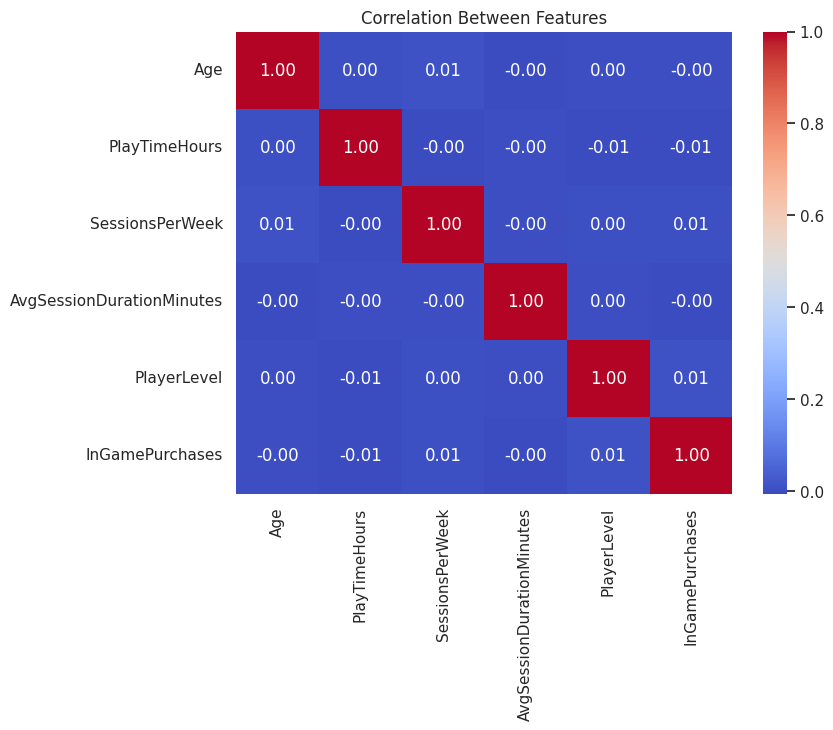

In [ ]:
# ================================
# CORRELATION HEATMAP
# ================================

import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Age', 'PlayTimeHours', 'SessionsPerWeek',
           'AvgSessionDurationMinutes', 'PlayerLevel', 'InGamePurchases']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Features')
plt.show()

## Analysis of Data


*From the histograms:*
- PlayTimeHours, SessionsPerWeek, AvgSessionDurationMinutes, and PlayerLevel: The charts have high similarities along the x-axis -> basic gaming habits—like how long or how often someone plays—are the same for both free and paying players. There is no evidence that playing more leads to buying more.

*From the barchart*
- Purchase rate by gender and difficulty: The rates of male players is higher for easy games (around 0.05) and difficult games(around 0.15) -> Difficulty might impacts each gender purchase decisions; however, the rates between two genders are pretty balanced.

*From the boxplots:*
- PlayTimeHours & AvgSessionDurationMinutes: The medians of the two groups are on the same -> Average time per session and total amount of time do not impact purchase decision.
- SessionsPerWeek: There is a tiny increase in the number of sesions for the "Purchased" group.
- PlayerLevel: Players at all levels have the same in-game purchase rate.

*From the correlation heatmap*
- The values are either 0 or 0.1 -> There is a weak correlation between the variables. This means the features are independent of each other and it is hard to predict purchase rate using only these basic behaviors.

**In conclusion**
1. Can behavior reliably predict in-game purchases? -> No
2. Patterns:
- The "Equal Distribution" Pattern: The data is very evenly spread out. For example, the PlayTimeHours charts show a flat, rectangular shape for both buyers and non-buyers, meaning players are just as likely to play 5 hours as they are 20 hours.
- The bar chart also shows that Male players on Easy and Medium difficulty have a slightly higher purchase rate (at around 20%) compared to Female, but the difference is very small .
3. Anomalies:
- Statistical outliers in PlayTimeHours and SessionsPerWeek might indicate data entry errors.
- Behavioral anomalies exist where high-level players on 'Hard' difficulty make zero purchases.
- The unusual lack of correlation (0.00) between engagement and spending is an anomaly that suggests the dataset may have potential biases or limitations in how it was recorded.

##Machine Learning
Question: Can patterns in player level of engagement (easy, medium, hard) and gameplay behavior reliably predict in-game purchasing behavior?


We chose Decision Tree and Logistic Regression because our research question is a supervised classification problem — predicting whether a player will make in-game purchases (a labeled target variable). K-Means is an unsupervised clustering algorithm that groups similar data points without using labels, which does not align with our prediction goal.

In [ ]:
# Drop playerID (no use in predicting)
if 'PlayerID' in df.columns:
    df = df.drop(['PlayerID'], axis=1)

# Label encoding
ordinal_mapping = {
  'GameDifficulty': {'Easy': 0, 'Medium': 1, 'Hard':2},
  'EngagementLevel': {'Low': 0, 'Medium': 1, 'High': 2}
}
for col, mapping in ordinal_mapping.items():
    # Only map if the column exists and is still of object type (not yet mapped)
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map(mapping)

# One-hot encoding
cols_to_onehot = [col for col in ['Gender', 'Location', 'GameGenre'] if col in df.columns and df[col].dtype == 'object']
if cols_to_onehot:
    df = pd.get_dummies(df, columns=cols_to_onehot, drop_first=True)

df.head()

,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,16.271119,0,1,6,108,79,25,1,True,False,True,False,False,False,False,True
1,29,5.525961,0,1,5,144,11,10,1,False,False,False,True,False,False,False,True
2,22,8.223755,0,0,16,142,35,41,2,False,False,False,True,False,False,True,False
3,35,5.265351,1,0,9,85,57,47,1,True,False,False,True,False,False,False,False
4,33,15.531945,0,1,2,131,95,37,1,True,True,False,False,False,False,False,False


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                               roc_auc_score, roc_curve)

# ============= 1. SPLIT =============
X = df.drop('InGamePurchases', axis=1)
y = df['InGamePurchases']

trainX, testX, trainY, testY = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============= 2. SCALE =============
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(trainX)
X_test_scaled = scaler.transform(testX)

# ============= 3. TRAIN =============
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(trainX, trainY)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, trainY)

dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced',
                              min_samples_leaf=10, random_state=42)
dt.fit(trainX, trainY)

DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=10, random_state=42)

In [ ]:
# ============= 4. EVALUATE =============
models_eval = {
    'Dummy (Baseline)': (dummy, testX),
    'Logistic Regression': (logreg, X_test_scaled),
    'Decision Tree': (dt, testX)
}

results = {}
for name, (model, X_te) in models_eval.items():
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(testY, proba)

    results[name] = {'pred': pred, 'proba': proba, 'auc': auc}

    print(f"\n=== {name} ===")
    print(classification_report(testY, pred, zero_division=0))
    print(f"ROC-AUC: {auc:.4f}")


=== Dummy (Baseline) ===
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6399
           1       0.00      0.00      0.00      1608

    accuracy                           0.80      8007
   macro avg       0.40      0.50      0.44      8007
weighted avg       0.64      0.80      0.71      8007

ROC-AUC: 0.5000

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.51      0.62      6399
           1       0.20      0.49      0.29      1608

    accuracy                           0.51      8007
   macro avg       0.50      0.50      0.46      8007
weighted avg       0.68      0.51      0.56      8007

ROC-AUC: 0.5020

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      6399
           1       0.20      0.26      0.22      1608

    accuracy                           0.63      8007
   macro avg      

In [ ]:
# ============= 5. FEATURE IMPORTANCE =============
dt_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

lr_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).assign(abs_coef=lambda d: d['coefficient'].abs())\
  .sort_values('abs_coef', ascending=False)

print("\n=== Decision Tree - Top Features ===")
print(dt_importance.head(10))

print("\n=== Logistic Regression - Top Coefficients ===")
print(lr_coef[['feature', 'coefficient']].head(10))


=== Decision Tree - Top Features ===
                      feature  importance
4   AvgSessionDurationMinutes    0.270981
8                 Gender_Male    0.167629
7             EngagementLevel    0.165341
6        AchievementsUnlocked    0.158375
5                 PlayerLevel    0.120090
14           GameGenre_Sports    0.117583
3             SessionsPerWeek    0.000000
2              GameDifficulty    0.000000
0                         Age    0.000000
1               PlayTimeHours    0.000000

=== Logistic Regression - Top Coefficients ===
                      feature  coefficient
7             EngagementLevel     0.054656
15         GameGenre_Strategy     0.047350
4   AvgSessionDurationMinutes    -0.035110
13       GameGenre_Simulation     0.032384
10             Location_Other    -0.026295
11               Location_USA    -0.023738
3             SessionsPerWeek    -0.022388
14           GameGenre_Sports     0.021167
8                 Gender_Male     0.013104
1               PlayTi

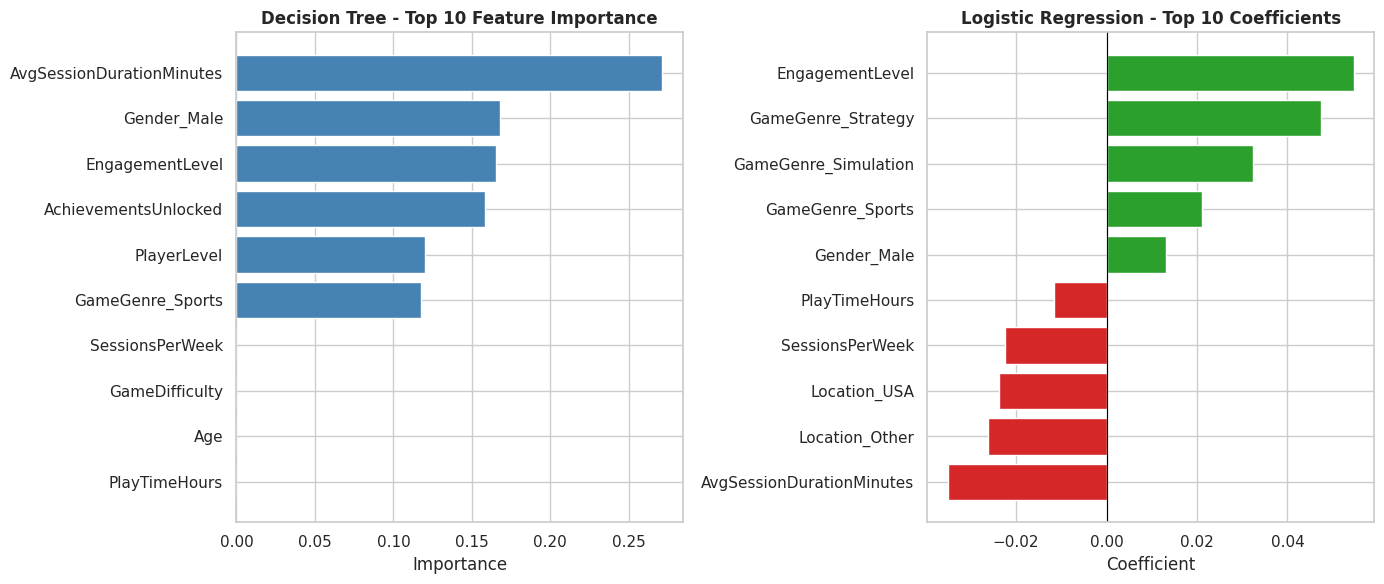

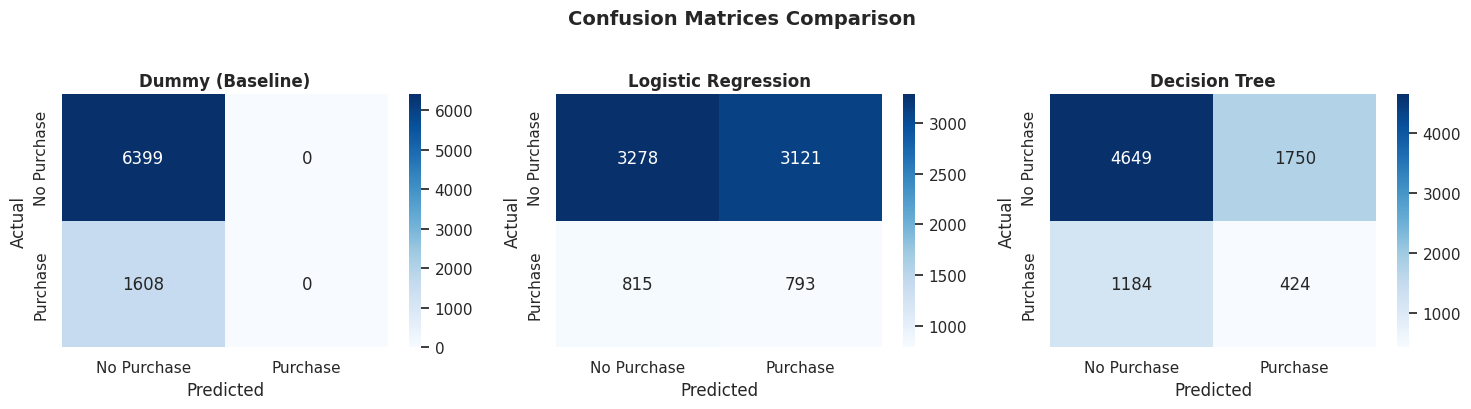

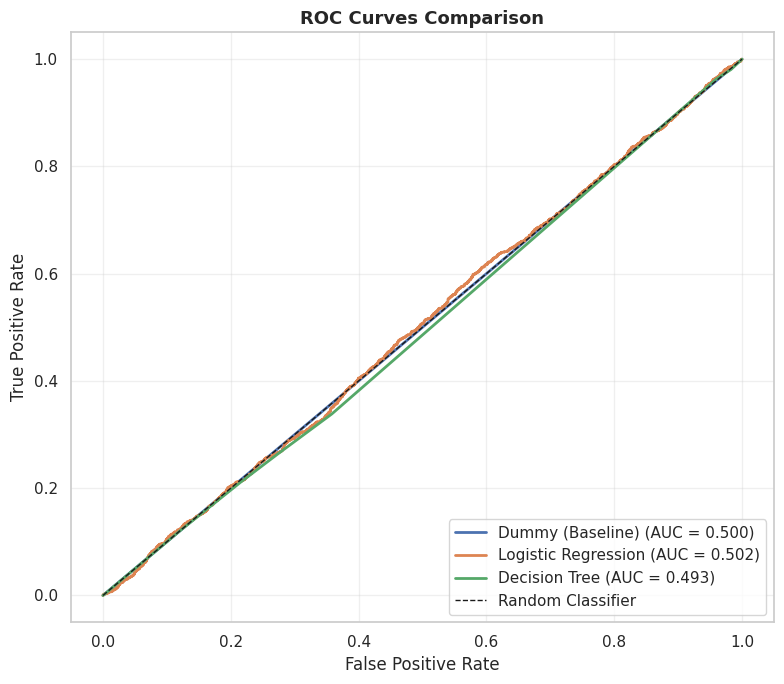

In [ ]:
# ============= 6. VISUALIZE FEATURE IMPORTANCE =============
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_imp = dt_importance.head(10)
axes[0].barh(top_imp['feature'], top_imp['importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Decision Tree - Top 10 Feature Importance', fontweight='bold')
axes[0].invert_yaxis()

top_coef = lr_coef.head(10).sort_values('coefficient')
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_coef['coefficient']]
axes[1].barh(top_coef['feature'], top_coef['coefficient'], color=colors)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Logistic Regression - Top 10 Coefficients', fontweight='bold')

plt.tight_layout()
plt.show()

# ============= 7. CONFUSION MATRICES =============
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(testY, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============= 8. ROC CURVES =============
plt.figure(figsize=(8, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(testY, res['proba'])
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

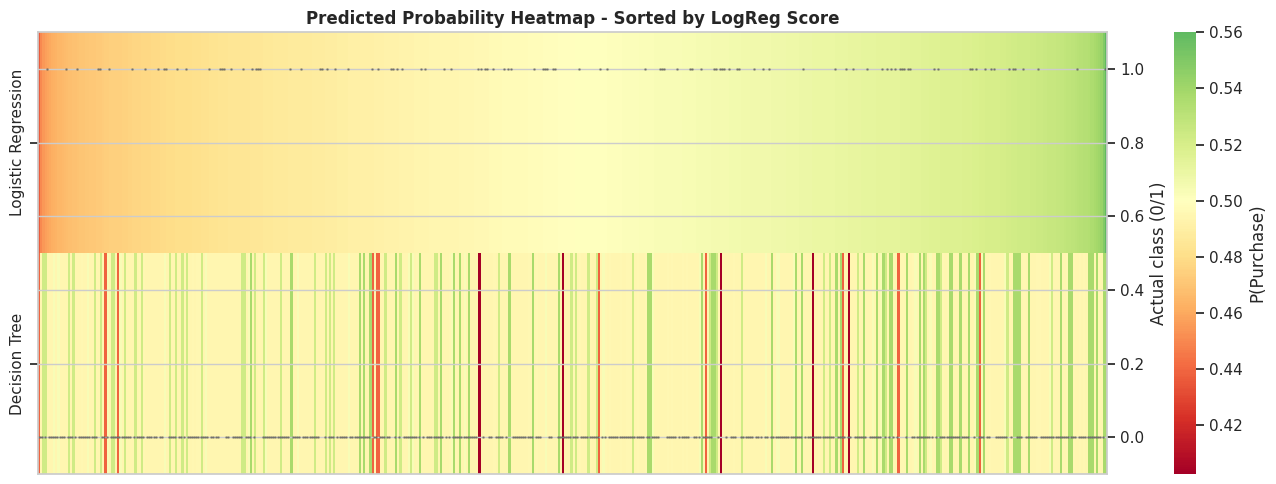

In [ ]:
# Create probability DataFrame
proba_df = pd.DataFrame({
    'Logistic Regression': results['Logistic Regression']['proba'],
    'Decision Tree': results['Decision Tree']['proba'],
    'Actual': testY.values
})

# Sort by LogReg probability to reveal patterns
proba_df = proba_df.sort_values('Logistic Regression').reset_index(drop=True)

# Sample 500 points to keep the plot readable
sample_idx = np.linspace(0, len(proba_df)-1, 500).astype(int)
proba_sample = proba_df.iloc[sample_idx]

# Draw heatmap
fig, ax = plt.subplots(figsize=(14, 5))
heatmap_data = proba_sample[['Logistic Regression', 'Decision Tree']].T
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0.5, ax=ax,
            cbar_kws={'label': 'P(Purchase)'},
            xticklabels=False)

# Overlay actual class indicators
ax2 = ax.twinx()
ax2.plot(proba_sample['Actual'].values, 'k.', alpha=0.3, markersize=2)
ax2.set_ylabel('Actual class (0/1)')
ax2.set_ylim(-0.1, 1.1)

plt.title('Predicted Probability Heatmap - Sorted by LogReg Score',
          fontsize=12, fontweight='bold')
plt.xlabel('Test samples (sorted)')
plt.tight_layout()
plt.show()

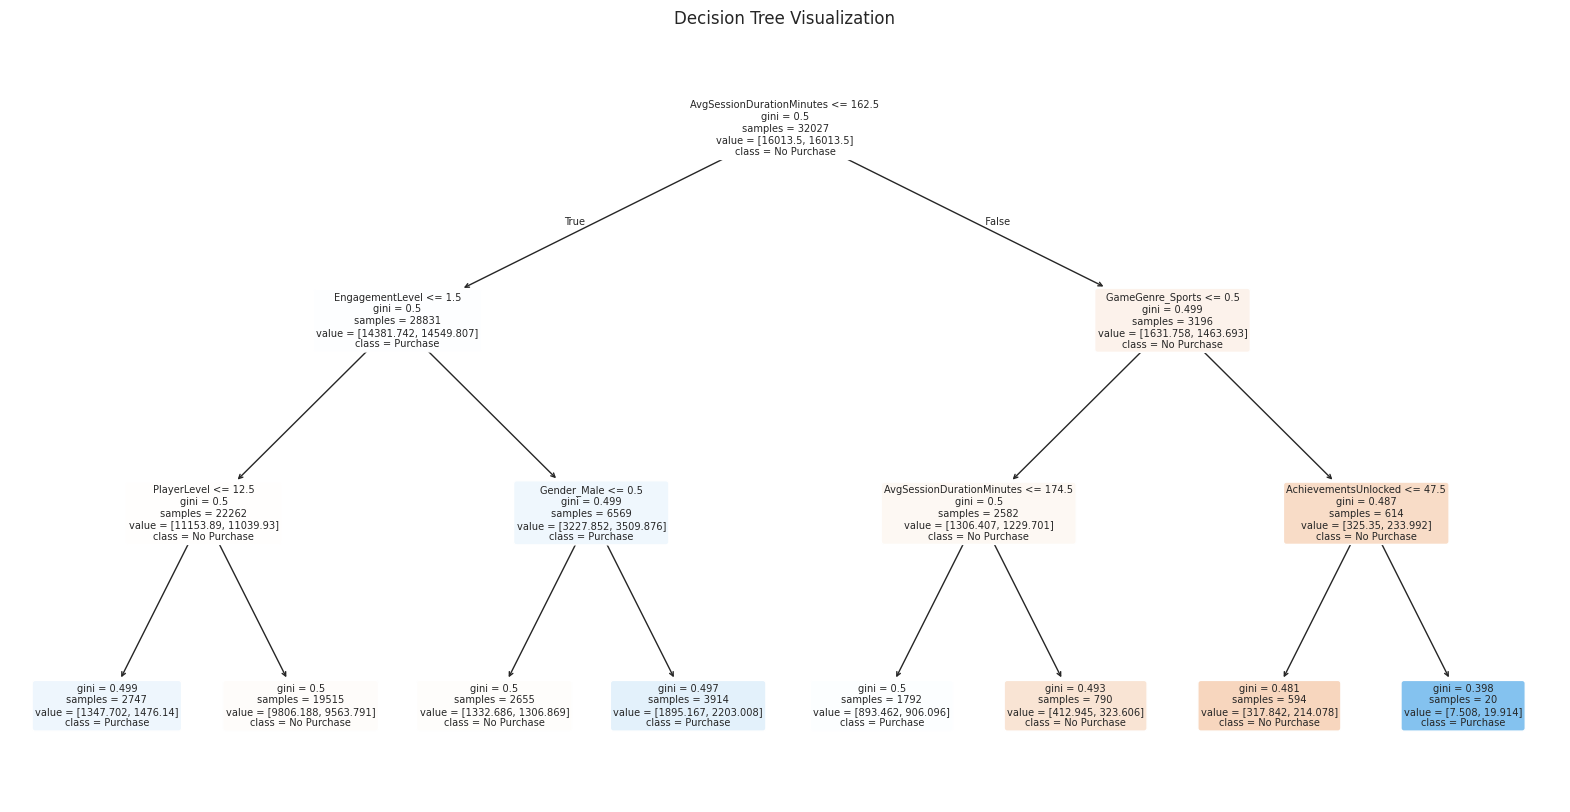

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No Purchase', 'Purchase'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

## ML Analysis & Conclusion

### Research Question
*Can patterns in player level of engagement and gameplay behavior reliably
predict in-game purchasing behavior?*

### Answer: **No, behavioral patterns cannot reliably predict in-game purchases.**

### Evidence Summary

| Model | Accuracy | F1 (Purchase=1) | ROC-AUC |
|---|---|---|---|
| Dummy Baseline | 0.80 | 0.00 | 0.500 |
| Logistic Regression | 0.51 | 0.29 | 0.502 |
| Decision Tree | 0.63 | 0.22 | 0.493 |

### Key Findings

**1. All three models perform near random chance.** Both ML models achieve
ROC-AUC values around 0.50 (Logistic Regression: 0.502, Decision Tree: 0.493),
which is essentially equivalent to random guessing. Notably, Decision Tree's
ROC-AUC of 0.493 is even slightly *below* 0.5, meaning it performs marginally
worse than flipping a coin.

**2. The Dummy Baseline shows why accuracy alone is misleading.** The Dummy
classifier achieves the highest accuracy (80%) by always predicting "No
Purchase," exploiting the class imbalance (~4:1). However, its F1-score for
the Purchase class is 0 — it catches zero actual purchasers. This demonstrates
why ROC-AUC and F1-score are more informative than accuracy for imbalanced data.

**3. Decision Tree only used 6 out of 16 features.** With `max_depth=3`, the
tree relied on:
- AvgSessionDurationMinutes (importance: 0.27)
- Gender_Male (0.17)
- EngagementLevel (0.17)
- AchievementsUnlocked (0.16)
- PlayerLevel (0.12)
- GameGenre_Sports (0.12)

Several behavioral features that we hypothesized would matter — including
PlayTimeHours, SessionsPerWeek, GameDifficulty, and Age — received an
importance of 0.00, meaning the tree found them unhelpful for splitting data.

**4. Logistic Regression coefficients reveal weak linear effects.** The
strongest coefficients (after standardization) are:
- EngagementLevel: +0.055 (slightly increases purchase probability)
- GameGenre_Strategy: +0.047
- AvgSessionDurationMinutes: -0.035 (slightly decreases probability —
  counterintuitive)
- GameGenre_Simulation: +0.032

All coefficient magnitudes are very small (|β| < 0.06), indicating that even
the "most influential" features have minimal effect on predictions.

**5. The two models disagree on feature importance.** Decision Tree emphasizes
AvgSessionDurationMinutes, Gender, and AchievementsUnlocked, while Logistic
Regression emphasizes EngagementLevel and GameGenre features. This disagreement
is itself evidence that there is no stable underlying signal — different
algorithms latch onto different weak patterns rather than converging on the
same meaningful relationships.

**6. Visualizations confirm the lack of signal.**
- *Confusion Matrices*: Both ML models produce many false positives in
  attempting to identify purchasers
- *ROC Curves*: All three curves hug the diagonal (random) line
- *Probability Heatmap*: Predicted probabilities cluster in the uncertain zone
  (P ≈ 0.4-0.6) for both models, with actual purchasers distributed uniformly
  rather than concentrated where the models predict high probability

### Why Behavioral Patterns Failed to Predict Purchases

Our ML findings are consistent with the EDA observations of near-zero correlations
and uniform feature distributions. Several explanations:

1. **Missing critical features.** Purchase decisions likely depend on factors not
captured in this dataset:
   - Marketing campaign exposure or in-game promotions
   - Social influence (friends making purchases)
   - Player mood, life context, or financial situation
   - Specific in-game events or limited-time offers
   - Payment method availability

2. **Possible synthetic data.** The unusually uniform distributions of behavioral
features (visible in the EDA histograms) suggest this dataset may be synthetically
generated rather than collected from real player behavior. Real gaming data
typically shows skewed distributions (most players play casually, a small minority
play heavily). The absence of this pattern explains the absence of predictive
signal.

3. **Behavioral metrics are insufficient by themselves.** Real-world gaming research
shows that purchase decisions involve psychological, social, and contextual factors
that go beyond simple play metrics like hours played or sessions per week.

### Conclusion

The answer to our research question is **no**: in this dataset, patterns in
engagement and gameplay behavior cannot reliably predict in-game purchases.
However, this is a **scientifically valuable finding** that demonstrates several
important data science principles:

- The importance of comparing models against baselines (the Dummy classifier
  revealed the trap of relying on accuracy alone)
- Using multiple metrics rather than a single one, especially with imbalanced data
- Recognizing when a dataset lacks the necessary features for a prediction task,
  rather than overfitting to noise

For future work, we recommend:
- Collecting richer behavioral data (timestamps, social interactions, marketing
  exposure)